### We will be performing all the necessary machine learning operations !

In [4]:
### Importing all the necessary libraries 

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score, confusion_matrix, recall_score, accuracy_score, ConfusionMatrixDisplay,f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC


In [5]:
### Dataset we will be using 
data = pd.read_csv('../Datasets/formodel.csv')
data.drop(columns="Unnamed: 0", inplace = True)
data.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,0,0,1,0,1,0,0,0,1,0,1,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,1,1,0,0,0,0,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,0,1,0,1,1,0,0,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,0,70.70,151.65,1


### Since we have alrady done the feature engineering and correctd the datatypes and filled the missing values, we are directly moving to the model creation. 

In [6]:
### Lets see the distribution of the y class
print(data['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [7]:
## Splitting the data into train test split 
RANDOM_SEED = 42
X = data.drop(columns = 'Churn')
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

### Model One: Logistic Regression 

In [8]:
pipeline_steps = [('scaler',StandardScaler()),('logit_model',LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED))]
logit_pipeline = Pipeline(pipeline_steps)

###As there is high class imbalance we will be using class_weight = 'balanced' and the StratifiedKFold to address the issue

params = {'logit_model__C':[0.01,0.1,1,10,100], 'logit_model__penalty':['l1','l2']}

### Hyperparameter tuning
kf = StratifiedKFold(n_splits=5,shuffle=True, random_state=RANDOM_SEED)
logit_model = GridSearchCV(logit_pipeline, param_grid = params, cv = kf)
tuned_model = logit_model.fit(X_train,y_train)
logit_model = tuned_model.best_estimator_

/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and w

In [9]:
logit_testing_pred = logit_model.predict(X_test)
logit_training_pred = logit_model.predict(X_train)

logit_testing_proba = logit_model.predict_proba(X_test)
logit_training_proba = logit_model.predict_proba(X_train)



### Metrics for the calcuation of the model performance 

Logit Testing Accuracy Score: 0.73
Logit Training Accuracy Score: 0.75
Precision Score: 0.50
Recall Score: 0.80
F1-Score: 0.61
Logit False Positive Rate: 0.29
Logit False Negative Rate: 0.20


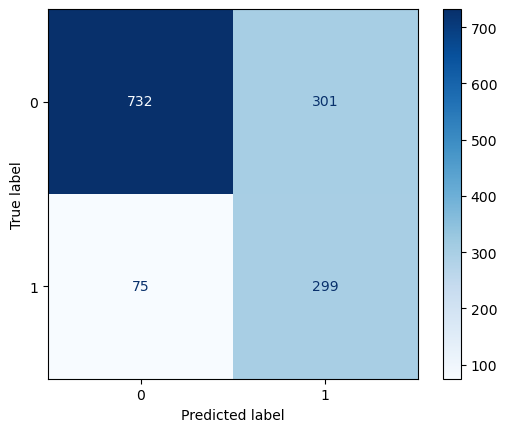

In [10]:
## Accuracy Score calculation
logit_testing_accruacy = accuracy_score(y_test, logit_testing_pred)
print(f"Logit Testing Accuracy Score: {logit_testing_accruacy:.2f}")
logit_training_accuracy = accuracy_score(y_train, logit_training_pred)
print(f"Logit Training Accuracy Score: {logit_training_accuracy:.2f}")


logit_precision = precision_score(y_test, logit_testing_pred)
print(f"Precision Score: {logit_precision:.2f}")

logit_recall = recall_score(y_test,logit_testing_pred)
print(f"Recall Score: {logit_recall:.2f}")

logit_f1 = f1_score(y_test, logit_testing_pred)
print(f"F1-Score: {logit_f1:.2f}")

logit_matrix = confusion_matrix(y_test, logit_testing_pred)
true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, logit_testing_pred ).ravel()

logit_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
print(f"Logit False Positive Rate: {logit_false_positive_rate:.2f}")
logit_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
print(f"Logit False Negative Rate: {logit_false_negative_rate:.2f}")
logit_confusion = confusion_matrix(y_test, logit_testing_pred)

display = ConfusionMatrixDisplay(confusion_matrix = logit_confusion)
display.plot(cmap='Blues')
plt.show()

### Model 2: Naive Bayes Classifier 

In [11]:
naive_model = GaussianNB(var_smoothing=1e-9)
naive_model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
naive_testing_pred = naive_model.predict(X_test)
naive_training_pred = naive_model.predict(X_train)

naive_testing_proba = naive_model.predict_proba(X_test)
naive_training_proba = naive_model.predict_proba(X_train)

Logit Testing Accuracy Score: 0.74
Logit Training Accuracy Score: 0.76
Precision Score: 0.51
Recall Score: 0.72
F1-Score: 0.60
Logit False Positive Rate: 0.24
Logit False Negative Rate: 0.28


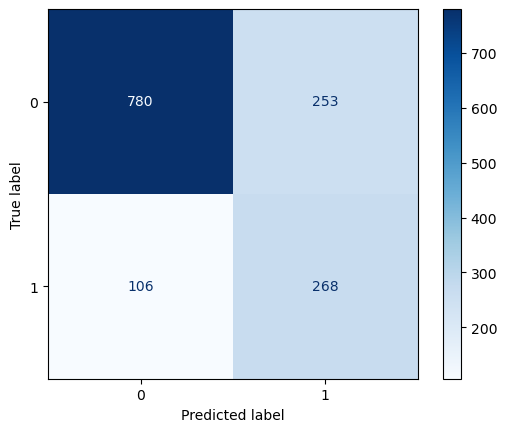

In [13]:
## Accuracy Score calculation
naive_testing_accruacy = accuracy_score(y_test, naive_testing_pred)
print(f"Logit Testing Accuracy Score: {naive_testing_accruacy:.2f}")
naive_training_accuracy = accuracy_score(y_train, naive_training_pred)
print(f"Logit Training Accuracy Score: {naive_training_accuracy:.2f}")

## Precsion score 

naive_precision = precision_score(y_test, naive_testing_pred)
print(f"Precision Score: {naive_precision:.2f}")

### Recall score 

naive_recall = recall_score(y_test,naive_testing_pred)
print(f"Recall Score: {naive_recall:.2f}")

## F1 Score 

naive_f1 = f1_score(y_test, naive_testing_pred)
print(f"F1-Score: {naive_f1:.2f}")

## Confusion Matrix 


naive_matrix = confusion_matrix(y_test, naive_testing_pred)
true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, naive_testing_pred ).ravel()

### False Positive and False Negative Rate 


naive_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
print(f"Logit False Positive Rate: {naive_false_positive_rate:.2f}")
naive_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
print(f"Logit False Negative Rate: {naive_false_negative_rate:.2f}")

### Plotting the confusion matrix 
display = ConfusionMatrixDisplay(confusion_matrix = naive_matrix)
display.plot(cmap='Blues')
plt.show()







---

### Linear SVM Model 

In [19]:
pipeline_steps = [('scaler', StandardScaler()),('svm', LinearSVC(loss= 'hinge'))]
svm_model = Pipeline(pipeline_steps)

### Hyperparmeter tuning for linear svm model 

params = {'svm__C':[1e-4, 1e-3, 1e-2, 1e-1, 1,10,100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
hyperparameters = GridSearchCV(svm_model, cv = kf, param_grid=params )

## Linear model selection 

hyperparameters.fit(X_train,y_train)

best_svm = hyperparameters.best_estimator_


/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/

In [21]:
svm_testing_pred = best_svm.predict(X_test)
svm_training_pred = best_svm.predict(X_train)

svm_testing_proba = best_svm.decision_function(X_test)
svm_training_proba = best_svm.decision_function(X_train)

In [ ]:
### Evaluation of the model's performance. 

## Accuracy Score calculation
svm_testing_accruacy = accuracy_score(y_test, svm_testing_pred)
print(f"Linear SVM Testing Accuracy Score: {svm_testing_accruacy:.2f}")
svm_training_accuracy = accuracy_score(y_train, svm_training_pred)
print(f"Linear SVM Training Accuracy Score: {svm_training_accuracy:.2f}")


### Model's precision 

## Precsion score 

svm_precision = precision_score(y_test, svm_testing_pred)
print(f"Precision Score: {svm_precision:.2f}")

# ### Recall score 

# svm_recall = recall_score(y_test,svm_testing_pred)
# print(f"Recall Score: {svm_recall:.2f}")

# ## F1 Score 

# naive_f1 = f1_score(y_test, naive_testing_pred)
# print(f"F1-Score: {naive_f1:.2f}")

# ## Confusion Matrix 


# naive_matrix = confusion_matrix(y_test, naive_testing_pred)
# true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, naive_testing_pred ).ravel()

# ### False Positive and False Negative Rate 


# naive_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
# print(f"Logit False Positive Rate: {naive_false_positive_rate:.2f}")
# naive_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
# print(f"Logit False Negative Rate: {naive_false_negative_rate:.2f}")

# ### Plotting the confusion matrix 
# display = ConfusionMatrixDisplay(confusion_matrix = naive_matrix)
# display.plot(cmap='Blues')
# plt.show()


Linear SVM Testing Accuracy Score: 0.79
Linear SVM Training Accuracy Score: 0.80
Precision Score: 0.64
